# Classification Test

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mlp import Layer, MLP
from losses import CrossEntropyLoss

from activations import LeakyRelu, SoftMax
from utils import OneHotEncoder
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=2,
    class_sep=2,
    random_state=1123344,
)
encoder = OneHotEncoder()
y_onehot = encoder.encode(y)
y_int = y                 


X_train, X_test = X[:400], X[400:]
y_train, y_test = y_onehot[:400], y_onehot[400:]

In [3]:
mlp = MLP()
mlp.add_layer(Layer(2, 16, LeakyRelu()))
mlp.add_layer(Layer(16, 8, LeakyRelu()))
mlp.add_layer(Layer(8, 2, SoftMax()))

In [4]:
loss_fn = CrossEntropyLoss()
l_rate = 0.1
epochs = 20

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for x, y in zip(X_train, y_train):
        y_hat = mlp.forward(x)
        epoch_loss += loss_fn.forward(y_hat, y)
        delta = loss_fn.backward(y_hat, y)
        mlp.backward(delta)
        mlp.update(l_rate)
    losses.append(epoch_loss / len(X_train))
    print(f"Epoch {epoch+1}/{epochs} - Loss: {losses[-1]}")


Epoch 1/20 - Loss: 0.1700769747873938
Epoch 2/20 - Loss: 0.10051934249481836
Epoch 3/20 - Loss: 0.09356980804238779
Epoch 4/20 - Loss: 0.08983416625103043
Epoch 5/20 - Loss: 0.09122998806343816
Epoch 6/20 - Loss: 0.08860498663186211
Epoch 7/20 - Loss: 0.09052432480568451
Epoch 8/20 - Loss: 0.08453252674657089
Epoch 9/20 - Loss: 0.0820596480008788
Epoch 10/20 - Loss: 0.08431946193060695
Epoch 11/20 - Loss: 0.08023164510564211
Epoch 12/20 - Loss: 0.08329170139754348
Epoch 13/20 - Loss: 0.0846007009236475
Epoch 14/20 - Loss: 0.08941131568902039
Epoch 15/20 - Loss: 0.08777400152751642
Epoch 16/20 - Loss: 0.09371296995987848
Epoch 17/20 - Loss: 0.08814142408254884
Epoch 18/20 - Loss: 0.08394849410356292
Epoch 19/20 - Loss: 0.08879689204358694
Epoch 20/20 - Loss: 0.08316974578227841


In [5]:
x = X_train[0]
y_true = y_train[0]
y_pred = mlp.forward(x)
delta = loss_fn.backward(y_pred, y_true)
mlp.backward(delta)

# check gradient at each layer
print("delta from loss:", delta)
print("layer3 grad_weights mean:", mlp.layers[2].grad_weights.mean())
print("layer2 grad_weights mean:", mlp.layers[1].grad_weights.mean())
print("layer1 grad_weights mean:", mlp.layers[0].grad_weights.mean())

delta from loss: [ 0.01246268 -0.01246268]
layer3 grad_weights mean: -6.324795017147861e-18
layer2 grad_weights mean: -0.0006666109646353501
layer1 grad_weights mean: -0.00608294273188434


In [6]:
correct = 0
for x, y in zip(X_test, y_test):
    y_pred = mlp.forward(x)
    if np.argmax(y_pred) == np.argmax(y):
        correct += 1

accuracy = correct / len(X_test)
print(f"Test accuracy: {accuracy * 100}%")

Test accuracy: 97.0%


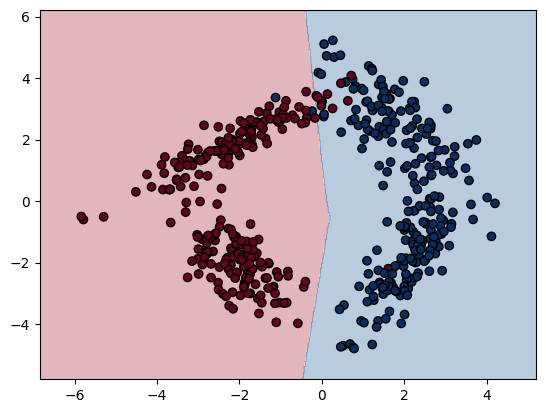

In [7]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([np.argmax(mlp.forward(point)) for point in grid])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y_onehot, axis=1), edgecolors='k', cmap='RdBu')
plt.show()